In [ ]:
import sys
from unittest.mock import Mock

# Creamos un modulo falso
mock_colab = Mock()

def mock_upload():
    print("Simulación: Deberias asegurarte de que el archivo .json ya esté en la carpeta local.")
    return {}

mock_colab.files.upload = mock_upload

# Lo inyectamos en los módulos del sistema (pero solo a google.colab, para no afectar a tensorflow)
sys.modules['google.colab'] = mock_colab

In [13]:
from google.colab import files

files.upload()

Simulación: Deberías asegurarte de que el archivo ya esté en la carpeta local.


{}

In [3]:
!pip install kaggle -q
import os


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\edysa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
# Configuramos Kaggle para que busque el archivo kaggle.json en la carpeta actual
os.environ['KAGGLE_CONFIG_DIR'] = os.getcwd()
print("Directorio de configuración de Kaggle establecido en:", os.environ['KAGGLE_CONFIG_DIR'])

Directorio de configuración de Kaggle establecido en: c:\Users\edysa\OneDrive\Desktop\Project-Grafica-Papa


In [ ]:
# Descargar y descomprimir el dataset en una carpeta especifica ('dataset_papa')
!kaggle datasets download -d faysalmiah1721758/potato-dataset --unzip -p dataset_papa
print("Dataset descargado y extraído correctamente en la subcarpeta.")

Dataset URL: https://www.kaggle.com/datasets/faysalmiah1721758/potato-dataset
License(s): CC0-1.0

Dataset descargado y extraído correctamente en la subcarpeta.



  0%|          | 0.00/37.8M [00:00<?, ?B/s]
  3%|▎         | 1.00M/37.8M [00:00<00:24, 1.55MB/s]
  5%|▌         | 2.00M/37.8M [00:00<00:13, 2.77MB/s]
  8%|▊         | 3.00M/37.8M [00:00<00:08, 4.16MB/s]
 11%|█         | 4.00M/37.8M [00:01<00:06, 5.16MB/s]
 13%|█▎        | 5.00M/37.8M [00:01<00:05, 6.29MB/s]
 19%|█▊        | 7.00M/37.8M [00:01<00:03, 8.08MB/s]
 24%|██▍       | 9.00M/37.8M [00:01<00:03, 9.19MB/s]
 29%|██▉       | 11.0M/37.8M [00:01<00:02, 10.3MB/s]
 34%|███▍      | 13.0M/37.8M [00:01<00:02, 10.5MB/s]
 40%|███▉      | 15.0M/37.8M [00:02<00:02, 11.1MB/s]
 45%|████▍     | 17.0M/37.8M [00:02<00:01, 11.2MB/s]
 50%|█████     | 19.0M/37.8M [00:02<00:01, 11.3MB/s]
 56%|█████▌    | 21.0M/37.8M [00:02<00:01, 11.8MB/s]
 61%|██████    | 23.0M/37.8M [00:02<00:01, 11.8MB/s]
 66%|██████▌   | 25.0M/37.8M [00:02<00:01, 11.8MB/s]
 71%|███████▏  | 27.0M/37.8M [00:03<00:00, 11.9MB/s]
 77%|███████▋  | 29.0M/37.8M [00:03<00:00, 12.0MB/s]
 82%|████████▏ | 31.0M/37.8M [00:03<00:00, 11.9MB/s]
 

In [18]:
# Instala las librerías necesarias para procesar las imágenes y crear los modelos
!pip install tensorflow matplotlib -q


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\edysa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# Definir hiperparametros de infraestructura
BATCH_SIZE = 32
IMG_SIZE = (224, 224) # Tamaño estándar para arquitecturas como MobileNet o ResNet

# Establecemos la carpeta donde acabamos de descargar las imágenes
DATA_DIR = "dataset_papa"

# Revisamos si Kaggle extrajo las clases dentro de una subcarpeta adicional
subcarpetas = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
if len(subcarpetas) == 1:
    DATA_DIR = os.path.join(DATA_DIR, subcarpetas[0])

# Conteo de distribución (filtrando solo carpetas)
clases = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
for clase in clases:
    num_imgs = len(os.listdir(os.path.join(DATA_DIR, clase)))
    print(f"Clase '{clase}': {num_imgs} imágenes")

# Creación del pipeline de Entrenamiento (80%)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Creación del pipeline de Validación (20%)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
print(f"Clases detectadas en el pipeline: {class_names}")

Clase 'Potato___Early_blight': 1000 imágenes
Clase 'Potato___healthy': 152 imágenes
Clase 'Potato___Late_blight': 1000 imágenes
Found 2152 files belonging to 3 classes.
Using 1722 files for training.
Found 2152 files belonging to 3 classes.
Using 430 files for validation.
Clases detectadas en el pipeline: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


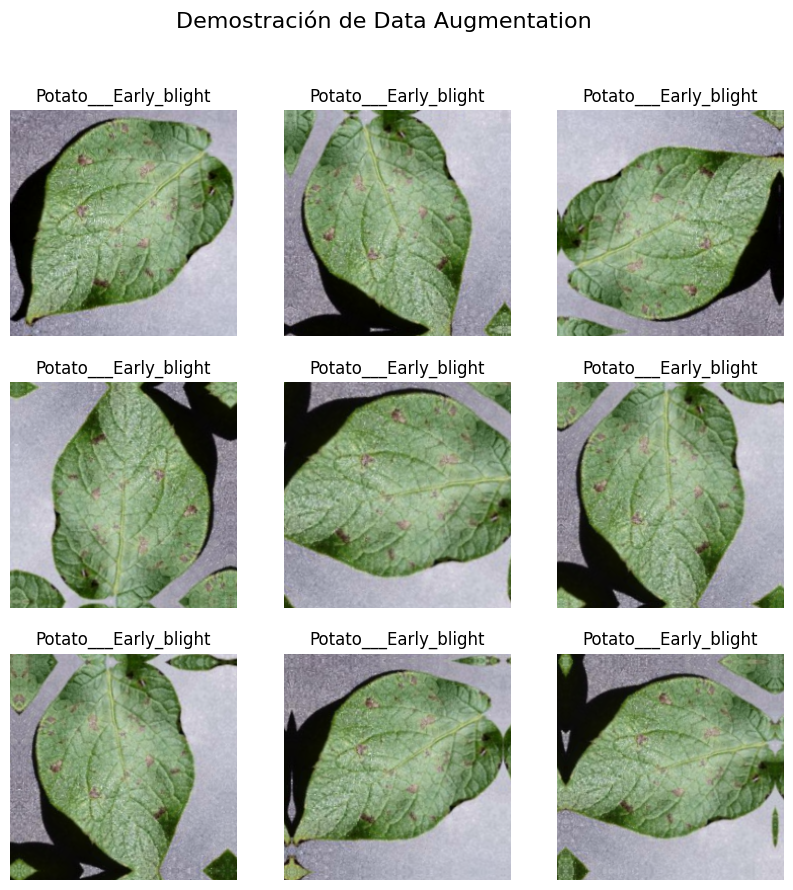

In [12]:
from tensorflow.keras import layers

# Definir la capa de aumento de datos secuencial
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2), # Rotación aleatoria del 20%
  layers.RandomZoom(0.1),
  layers.RandomContrast(0.1)  # Variación para simular distintas iluminaciones
])

# Visualizar el efecto del Data Augmentation para la presentación
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    # Tomar la primera imagen del batch
    first_image = images[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Aplicar el aumento a la misma imagen
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0] / 255.0) # Normalizar para matplotlib
        plt.title(class_names[labels[0]])
        plt.axis("off")
plt.suptitle("Demostración de Data Augmentation", fontsize=16)
plt.show()

In [10]:
# AUTOTUNE delega a TensorFlow la gestión del tamaño del buffer en tiempo de ejecución
AUTOTUNE = tf.data.AUTOTUNE

# Aplicar las optimizaciones de I/O
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("Pipelines de datos optimizados en memoria estática y asíncrona.")

Pipelines de datos optimizados en memoria estática y asíncrona.


### Script de Entrenamiento 

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models, callbacks
import tensorflow as tf

# 1. Cargar el modelo base preentrenado ResNet50
# include_top=False realizara que le quite la clasificación original (las 1000 clases de ImageNet: perro, gato, avión, auto, etc.)
# weights='imagenet' el modelo ya aprendio con millones de imágenes: bordes, formas, texturas, objetos y no entrenara desde cero
base_model = ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Congela todas las capas del modelo base para que sus pesos no cambien durante el entrenamiento
base_model.trainable = False 

# 2. Construir la arquitectura
model = models.Sequential([
    data_augmentation, 
    
    # Lambda aplica una función 'preprocess_input' que alinea 
    # los colores de las fotos para que encajen matemáticamente con lo que ResNet espera
    layers.Lambda(preprocess_input), 
    
    # El cerebro convolucional
    base_model,
    
    # Convertimos los mapas de características 2D a un vector 1D
    layers.GlobalAveragePooling2D(),
    
    # Apagamos neuronas al azar al 30% (Dropout) para obligar a que la red no memorice las hojas de papas
    layers.Dropout(0.3),
    
    # La salida real: capa densa del tamaño de 'class_names' (3: saludable, temprana, tardía)
    # Softmax da como salida porcentajes del 0 al 1
    layers.Dense(len(class_names), activation='softmax') 
])

# 3. Compilación del modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Aplicamos el optimizador Adam
    loss='sparse_categorical_crossentropy', # Función de pérdida (error)
    metrics=['accuracy'] # Precisión
)

# 4. Configurar Early Stopping (Script Avanzado)
# Si en 3 épocas el 'val_loss' (error en nuevos datos) no baja, detiene todo y evita un sobreajuste
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

# 5. Ejecutar el entrenamiento
print("Iniciando entrenamiento con arquitectura ResNet50...")
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15, # Limite maximo de rondas, pero tomamos en cuenta que Early Stopping detendrá antes si no hay mejora
    callbacks=[early_stopping]
)

# 6. Guardar el modelo
# .h5 es el formato en que TensorFlow guarda todo el bloque neuronal y pesos
model.save('modelo_papas_resnet50.h5')
print("Modelo ResNet guardado exitosamente.")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step

Iniciando entrenamiento con arquitectura ResNet50...
Epoch 1/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 36s 611ms/step - accuracy: 0.3339 - loss: 1.5594 - val_accuracy: 0.5977 - val_loss: 0.8070
Epoch 2/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 34s 631ms/step - accuracy: 0.6249 - loss: 0.8089 - val_accuracy: 0.7977 - val_loss: 0.5776
Epoch 3/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 34s 629ms/step - accuracy: 0.7445 - loss: 0.6406 - val_accuracy: 0.8698 - val_loss: 0.4544
Epoch 4/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 643ms/step - accuracy: 0.7979 - loss: 0.5061 - val_accuracy: 0.8884 - val_loss: 0.3787
Epoch 5/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 36s 675ms/step - accuracy: 0.8322 - loss: 0.4384 - val_accuracy: 0.9000 - val_loss: 0.3275
Epoch 6/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 37s 689ms/step - accuracy: 0.8589 - loss: 0.3838 - val_accuracy: 0.9070 - val_loss: 0.2933
Epoch 7/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 36s 670ms/step - accuracy: 0.8815 - loss: 0.3297 - val_accuracy: 0.9093 - val_loss

Modelo ResNet guardado exitosamente.
